<div style="padding:5px; border-radius:10px;background-color:lightsalmon;">
<h1 style="text-align:center;color:black;"> LP02 - TP - La récursivité</h1>
<h3 style="text-align:center;"> Terminale NSI</h3>
</div>

<div class="alert alert-info" style="border-left: 5px solid #ac763d;border-radius:2px;"> <b><u>Récursivité</b></u>

 Un algorithme (ou fonction) récursif est un algorithme (ou fonction) qui fait appel à lui-même. 



Un premier exemple est une notion vue en mathématique: les suites numériques.

On considère la suite $(u_n)$ définie pour tout entier naturel $n$ par $u_{n+1}=3u_n-1$ et $u_0=2$

Pour calculer $u_5$ il faudra calculer les valeurs de $u_4...u_1$ et enfin tomber sur le cas que l'on connait (valeur initiale), c'est à dire $u_0$.

Lorsqu'on programme grâce à la méthode récursive, il faut obtenir deux informations:
* le cas de base, la condition triviale, la condition d'arrêt: la seule chose dont on soit certain.
* une relation entre un cas à un instant $n$ et ce même cas à l'instant $n+1$. En mathématiques, on parlera de relation de récurrence.

Ici on peut déterminer facilement les deux informations.

Un programme récursif est toujours structuré de la même manière:

```code
DECLARATION DE LA FONCTION (PARAMETRES):
    SI LE CAS TRIVIAL EST ATTEINT:
        ON RENVOIE UNE VALEUR TRIVIALE
    SINON:
        MODIFICATION EVENTUELLE DES PARAMETRES
        APPEL RECURSIF
```


In [1]:
### Implémentation de la suite (u_n)
def suite_u(n):
    ''' Renvoie la valeur du terme de rang n'''
    # Cas trivial
    if n == 0:
        return 2
    else:
        n = n - 1
        return 3 * suite_u(n) - 1
    

Si on examine ce qu'il se passe et dans quel ordre les appels sont effectués. La fonction appelée est `suite_u(5)`

| Fonction appelée | IF | n | RETURN |Valeur renvoyée|
|:----------------:|:----------------:|:----------------:|:----------------:|:----------------:|
|suite_u(5)|False|5|3 * suite_u(4) - 1|3 * 122 - 1 = 365|
|suite_u(4)|False|4|3 * suite_u(3) - 1|3 * 41 - 1 = 122|
|suite_u(3)|False|3|3 * suite_u(2) - 1|3 * 14 - 1 = 41|
|suite_u(2)|False|2|3 * suite_u(1) - 1|3 * 5 - 1 = 14|
|suite_u(1)|False|1|3 * suite_u(0) - 1|3 * 2 - 1 = 5|
|suite_u(0)|True|0|2|2|


1. `suite_u(5)` attend la fin de `suite_u(4)`
2. `suite_u(4)` attend la fin de `suite_u(3)`
3. `suite_u(3)` attend la fin de `suite_u(2)`
4. `suite_u(2)` attend la fin de `suite_u(1)`
5. `suite_u(1)` attend la fin de `suite_u(0)`
6. Condition triviale: `suite_u(0)` renvoie `2`
7. On peut finir la ligne 5. et `suite_u(1)` renvoie son résultat
8. On peut finir la ligne 4. et `suite_u(2)` renvoie son résultat
9. On peut finir la ligne 3. et `suite_u(3)` renvoie son résultat
10. On peut finir la ligne 2. et `suite_u(4)` renvoie son résultat
11. On peut finir la ligne 1. et `suite_u(5)` renvoie son résultat



Il faut imaginer qu'on a empiler des appels de fonctions jusqu'au moment où la condition triviale est atteinte. A ce moment-là on va dépiler les différents appels.

Il faut imaginer que la colonne `RETURN` se lit de haut en bas et une fois la condition triviale atteinte on passe dans la colonne `Valeur renvoyée` que l'on lit de bas en haut. 

Visualisez ce qu'il se passe lors de l'appel de cette fonction avec `Python Tutor`


<div class="alert alert-success" style="border-left: 5px solid #3c763d;border-radius:2px;"> <b><u>Exercice 1</b></u>:

On considère la fonction qui peut être définie de la manière suivante: Pour tout nombre réel non nul $a$, et tout entier naturel $n$ on a:

$$
\begin{cases}
a^0 = 1 \\
a^{n} = a \times a^{n-1} & \text{si } n \neq 0 
\end{cases}$$

1. Compléter la fonction puissance en version itérative


In [5]:
def puissance_iterative(a, n):
    ''' Calcule la valeur de a**n de manière itérative'''
    puissance = 1
    for i in range(n):
        puissance = puissance * a
    return puissance

In [6]:
assert puissance_iterative(2, 0) == 1
assert puissance_iterative(2, 8) == 256

2. Compléter la fonction puissance en version récursive

* Condition triviale: `si n est égal à 0` alors $a^0=1$
* Sinon on voit une relation de récurrence (récursivité) telle que $a^{n} = a \times a^{n-1}$

In [7]:
def puissance_recursive(a, n):
    ''' Calcule la valeur de a**n de manière récursive '''
    if n == 0:
        return 1
    else:
        return a * puissance_recursive(a, n-1)

In [8]:
assert puissance_recursive(2, 0) == 1
assert puissance_recursive(2, 8) == 256

3. Faire une trace de l'appel de `puissance_recursive(2, 5)`

<div class="alert alert-success" style="border-left: 5px solid #3c763d;border-radius:2px;"> <b><u>Exercice 2</b></u>:

La fonction factorielle est une fonction mathématique qui est définie par:

$$
\begin{cases}
0! = 1 \\
n! = n \times (n-1) \times (n-2) \times \ldots \times 2 \times 1 & \text{si } n \neq 0 
\end{cases}$$

Ecrire une version itérative et une fonction récursive de la fonction `facto`

In [1]:
def facto_iteratif(n):
    ''' Calcule n! de manière itérative '''
    facto = 1
    for i in range(1, n+1):
        facto *= i
    return facto

In [2]:
def facto_recursif(n):
    ''' Calcule n! de manière récursive '''
    if n == 0:
        return 1
    else:
        return n * facto_recursif(n-1)

In [ ]:
facto_iteratif(3)

<div class="alert alert-info" style="border-left: 5px solid #ac763d;border-radius:2px;"> <b><u>Récursivité croisées</b></u>

Il peut arriver qu'un `fonction 1` appelle une `fonction 2` qui elle-même appelle une `fonction 1`. Dans ce cas, nous avons une récursivité croisée.


<div class="alert alert-success" style="border-left: 5px solid #3c763d;border-radius:2px;"> <b><u>Exercice 3</b></u>:

Ecrire deux fonctions récursives:

* `est_pair(n:int)` qui renvoie `True` si `n` est pair et appelle la fonction `est_impair(n-1)` sinon
* `est_impair(n:int)` qui renvoie `True` si `n` est impair et appelle la fonction `est_pair(n-1)` sinon

In [1]:
def est_pair(n:int):
    ''' Renvoie True si n est pair '''
    if n == 1:
        return False
    if n == 0:
        return True
    else:
        return est_impair(n-1)

def est_impair(n:int):
    ''' Renvoie True si n est impair '''
    if n == 0:
        return False
    if n == 1:
        return True
    else:
        return est_pair(n-1)


In [ ]:
est_pair(7)

In [ ]:
def est_impair(n:int):
    ''' Renvoie True si n est impair '''

<div class="alert alert-success" style="border-left: 5px solid #3c763d;border-radius:2px;"> <b><u>Exercice 4</b></u>:

Ecrire sous forme récursive les suites $(u_n)$ et $(v_n)$ définies par $u_0=1$ et $v_0=2$ et pour tout $n$ entier naturel:

$$
\begin{cases}
u_n=3u_{n-1}+2v_{n-1} \\
v_n=2u_{n-1}+3v_{n-1}\end{cases}$$

Voici l'affichage demandé:

```code
u(0) = 1     v(0)=2
u(1) = 7     v(1)=8
u(2) = 37    v(2)=38
u(3) = 187   v(3)=188
u(4) = 937   v(4)=938
```


<div class="alert alert-info" style="border-left: 5px solid #ac763d;border-radius:2px;"> <b><u>Récursivité multiple</b></u>

Une récursivité multiple arrive lorsque une fonction s'appelle plusieurs fois. C'est par exemple le cas pour la suite de Fibonnaci:

$$
\begin{cases}
F(0)=0 \qquad F(1)=1 \\
F(n)=F(n-1)+F(n-2) \: \text{si } n >1\end{cases}$$


<div class="alert alert-success" style="border-left: 5px solid #3c763d;border-radius:2px;"> <b><u>Exercice 5</b></u>:

1. Ecrire sous forme récursive la fonction récursive `fibo(n:int)` qui renvoie le n-ième terme de la suite de Fibonacci.

In [ ]:
def fibo(n:int):
    ''' Renvoie le n-ième terme de la suite de Fibonacci'''
    # Cas de base
    if n == 0 or n == 1:
        return n
    # Recursivité
    else:
        return fibo(n-1) + fibo(n-2)

fibo(37)

2. Fabriquer la trace de l'appel `fibo(5)`

La figure ci-dessous représente les appels déclenchés par le calcul de fibo(5). Dans
le cas général, le nombre d’appels de ` fibo(n)` est exponentiel. C’est d’autant plus regrettable qu’on
effectue plusieurs fois les mêmes calculs. Par exemple le calcul de `fibo(5)` va indirectement déclencher
5 fois le calcul de `fibo(1)`. Nous pourrons donc optimiser ce fonctionnement.

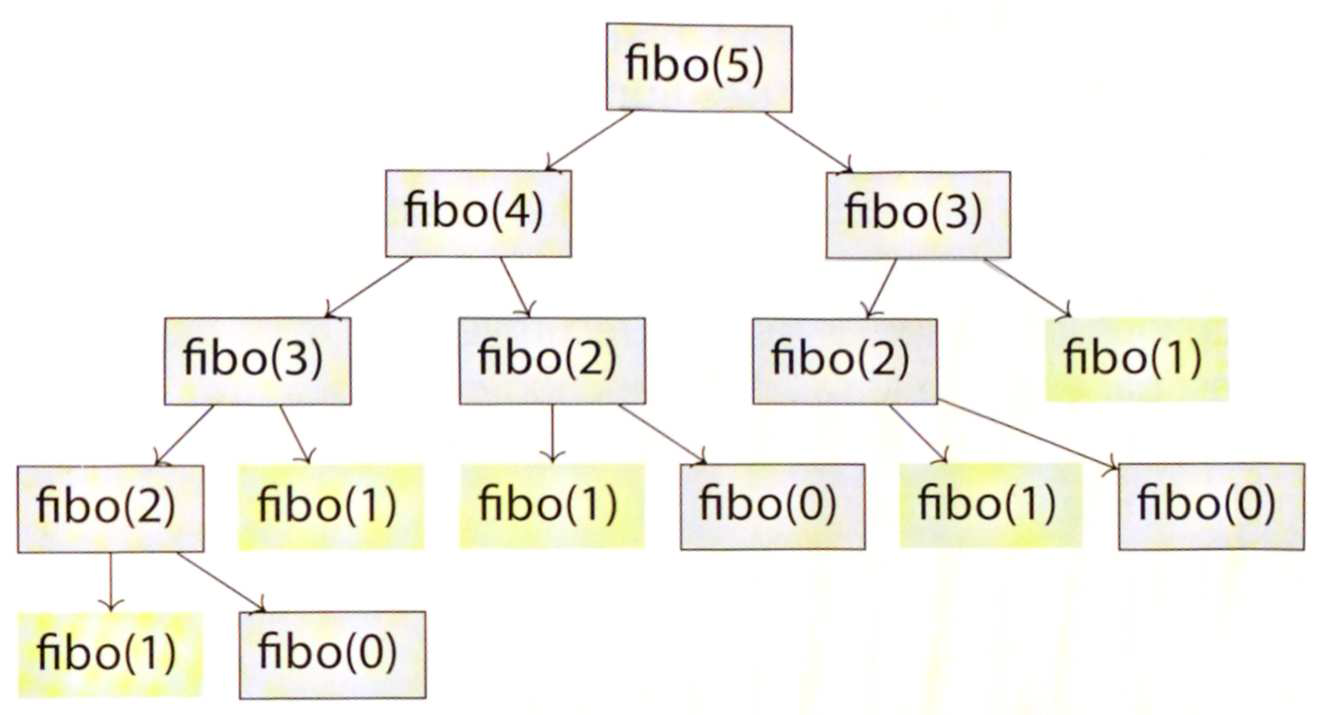

<div class="alert alert-success" style="border-left: 5px solid #3c763d;border-radius:2px;"> <b><u>Exercice 6</b></u>:

On appelle coefficient binomial le nombre caractérisé par:
$${n \choose k} = 
\begin{cases}
0 & \text{si } k > n \\
1 & \text{si } k = 0 \\
1 & \text{si } k = n \\
{{n-1}\choose{k-1}}+{{n-1}\choose k} & \text{sinon }
\end{cases}$$

1. Implémenter la fonction `coeff_binomial(n, k)`
2. Faire la trace de l'appel de `coeff_binomial(3, 2)`
 



In [8]:
def coeff_binomial(n, k):
    ''' Calcule le coefficient binomial k parmis n'''
    if k > n:
        return 0
    if k == 0 or k == n:
        return 1
    else:
        return coeff_binomial(n-1, k-1) + coeff_binomial(n-1, k)

In [ ]:
coeff_binomial(3, 2)

<div class="alert alert-success" style="border-left: 5px solid #3c763d;border-radius:2px;"> <b><u>Exercice 7</b></u>:


1. Donner une version récursive de la fonction calculant la somme des éléments d'une liste.

On pourra remarquer que:
* si la liste en comporte qu'un seul élément alors la somme des éléments de la liste est égal à cet élément
* la somme des éléments présents dans une  liste est la somme du premier élément et du reste de la liste.

On pourra utiliser le slicing de liste dans cet exercice:
* `L[1:]` est la liste `L` privée du premier élément
* `L[:-1]` est la liste `L` privée du dernier élément

In [14]:
def somme_elements_liste(L:[int]):
    ''' Calcule la somme des éléments présents dans une liste'''
    if L == []:
        return 0
    else:
        return L.pop() + somme_elements_liste(L)

In [ ]:
somme_elements_liste([1, 2, 3])

2. Ecrire une fonction récursive `binaire(n:int)` qui convertit une entier `n` compris entre 0 et 255 en valeur binaire au format chaine de caractère.

 

In [21]:
def binaire(n:int):
    ''' Convertit un entier naturel en mot binaire'''
    assert type(n) == int and 0 <= n <= 255
    ###
    if n == 0:
        return ''
    else:
        reste = n%2
        n = n//2
        return binaire(n) + str(reste)

In [ ]:
def binaire2(n:int):
    if n == 0:
        return ''
    else:
        return binaire2(n//2) + str(n%2)
binaire2(245)  

In [20]:
#assert binaire(0) == '0'
assert binaire(255) == '11111111'
assert binaire(4) == '100'

3. Ecrire une fonction récursive `maximum(L)` qui renvoie la valeur maximale de la liste `L`

In [32]:
def maximum(L:[int]):
    ''' Renvoie la valeur maximale de la liste L'''
    if len(L) == 1:
        return L[0]
    else:
        return max(L.pop(), maximum(L))
    
def maximum2(L):
    if len(L) == 1:
        return L[0]
    else:
        max(L[0], maximum(L[1:]))

In [33]:
assert maximum([1, 2, 3]) == 3
assert maximum([3, 2, 1]) == 3
assert maximum([1, 3, 2]) == 3

4. Ecrire une fonction récursive `quotient(a, b)` qui permet de calculer le quotient de la division euclidienne de `a` par `b`.

In [1]:
def quotient1(a:int, b:int):
    if a < b:
        return 0
    else:
        return 1 + quotient1(a-b, b)

In [43]:
def quotient(a:int, b:int, q=0):
    ''' Renvoie le quotient de la division euclidienne de a par b'''
    if a < b:
        return q
    else:
        a = a - b
        q = q + 1
        return quotient(a, b, q)

In [ ]:
quotient1(7, 2)

In [45]:
assert quotient(7, 2) == 3
assert quotient(3, 5) == 0

5. Ecrire la fonction récursive `reste(a, b)` qui permet de calculer le reste de la division euclidienne de `a` par `b`.

In [46]:
def reste(a:int, b:int):
    if a < b:
        return a
    else:
        a = a - b
        return reste(a, b)

In [47]:
assert reste(5, 2) == 1
assert reste(2, 3) == 2

6. Ecrire une fonction récursive `est_palindrome(mot:str)` qui renvoie `True` si `mot` est un palindrome et `False` sinon.

In [1]:
def est_palindrome(mot:str):
    # Si le mot fait 0 ou 1 caractère alors c'est un palindrome
    # Cas trivial
    if len(mot) == 0 or len(mot) == 1:
        return True
    else:
        # Si les caractères de d et g sont indentiques
        if mot[0] == mot[-1]:
            return est_palindrome(mot[1: -1])
        else:
            return False
    

In [2]:
assert est_palindrome('abccba') == True
assert est_palindrome('abcdcba') == True
assert est_palindrome('abcdba') == False


7. L'algorithme d'exponentiation rapide permet de calculer la valeur de $a^n$ de manière efficace. On remarque que:

$$a^{2n}=\left(a^n\right)^2 \qquad \text{et} \qquad a^{2n+1}=a \times \left(a^n\right)^2$$

* Ecrire une méthode récursive prenant deux entiers $a$ et $n$ en argument et renvoyant la valeur $a^n$  en appliquant récursivement celle des deux égalités qui correspond.
* Supposons que l'on calcule $2^{65}$ à l'aide de cette méthode. Donner la suite des appels récursifs effectués avec  leur imbrication
* Combien y a t-il d'appels provoqués par le calcul de $2^{16}$? $2^{32}$?, $2^{64}$?

In [50]:
def expo_rapide(a:int, n:int):
    if n == 0:
        return 1
    else:
        if n % 2 == 0:
            return expo_rapide(a, n//2) ** 2
        return a * expo_rapide(a, n//2) ** 2

In [ ]:
expo_rapide(2, 4)